# Task 2 — Heritage Crack Detection

**Model:** YOLOv8s (pretrained COCO, fine-tuned)  
**Dataset:** OmniCrack30k — masks converted to bounding boxes  
**Target:** mAP@50 > 70%  

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4 GPU"
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


GPU  : Tesla T4
VRAM : 15.6 GB


In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.9 MB/s eta 0:00:00


## 1. Mount Drive & Extract Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Drive contents:")
for f in sorted(DRIVE_DIR.iterdir()):
    print(f"  {f.name}")


Mounted at /content/drive
Drive contents:
  checkpoints
  crackforest.zip
  historical_crack.zip
  masonry.zip
  notebooks
  omnicrack30k.zip
  plots


In [ ]:
import zipfile, shutil, time
from google.colab import drive

OMNI_DIR = DATA_DIR / 'omnicrack30k'

if OMNI_DIR.exists() and any(OMNI_DIR.rglob('*.*')):
    print("Already extracted, skipping.")
else:
    zip_src   = DRIVE_DIR / 'omnicrack30k.zip'
    zip_local = Path('/content/omnicrack30k.zip')

    if not zip_local.exists():
        size_gb = zip_src.stat().st_size / 1e9
        print(f"Copying {size_gb:.2f} GB zip to local storage (~5-10 min)...")
        for attempt in range(1, 4):
            try:
                shutil.copy2(zip_src, zip_local)
                print("Copy done.")
                break
            except OSError as e:
                print(f"Attempt {attempt} failed ({e}). Remounting Drive...")
                if zip_local.exists():
                    zip_local.unlink()
                drive.mount('/content/drive', force_remount=True)
                time.sleep(5)
        else:
            raise RuntimeError("Drive copy failed after 3 attempts. Check Drive connection.")

    print("Unzipping...")
    with zipfile.ZipFile(zip_local, 'r') as zf:
        zf.extractall(DATA_DIR)
    print("Unzip done.")

    # Zip extracts flat — move into omnicrack30k/ subfolder
    if not OMNI_DIR.exists():
        OMNI_DIR.mkdir()
        for item in ['images', 'annotations', 'centerlines', 'masks']:
            src = DATA_DIR / item
            if src.exists():
                shutil.move(str(src), str(OMNI_DIR / item))
                print(f"  Moved {item}/")

print(f"Contents: {[p.name for p in sorted(OMNI_DIR.iterdir())]}")


## 2. Setup Paths & Splits

In [5]:
import cv2, numpy as np

IMG_ROOT = OMNI_DIR / 'images'
ANN_ROOT = OMNI_DIR / 'annotations'
EXTS     = {'.jpg', '.jpeg', '.png', '.bmp'}
SPLITS   = ['training', 'validation', 'test']

# Use dataset's predefined splits
split_imgs = {}
for split in SPLITS:
    imgs = sorted([
        p for p in (IMG_ROOT / split).rglob('*')
        if p.suffix.lower() in EXTS and p.is_file()
    ])
    split_imgs[split] = imgs
    print(f"{split:12}: {len(imgs)} images")

all_imgs = [p for imgs in split_imgs.values() for p in imgs]
print(f"\nTotal images : {len(all_imgs)}")

# stem -> mask path lookup
mask_lookup = {
    p.stem: p
    for split in SPLITS
    for p in (ANN_ROOT / split).rglob('*')
    if p.suffix.lower() in EXTS and p.is_file()
}
print(f"Masks found  : {len(mask_lookup)}")


training    : 22158 images
validation  : 3277 images
test        : 4582 images

Total images : 30017
Masks found  : 29884


## 3. Convert Masks → YOLO Labels

Binary mask → bounding boxes via contours.  
Labels written to `labels/<split>/` mirroring image structure so YOLO can find them.

In [ ]:
def mask_to_yolo_labels(mask_path, min_area=200, max_aspect=4, n_segments=3):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    labels = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect = max(bw, bh) / (min(bw, bh) + 1e-6)
        if aspect > max_aspect:
            # split long crack along dominant axis — tighter boxes, less background
            if bw >= bh:
                seg_w = bw // n_segments
                for i in range(n_segments):
                    sx = x + i * seg_w
                    sw = seg_w if i < n_segments - 1 else bw - i * seg_w
                    cx = (sx + sw / 2) / w
                    cy = (y + bh / 2) / h
                    labels.append(f"0 {cx:.6f} {cy:.6f} {min(sw/w,1.):.6f} {min(bh/h,1.):.6f}")
            else:
                seg_h = bh // n_segments
                for i in range(n_segments):
                    sy = y + i * seg_h
                    sh = seg_h if i < n_segments - 1 else bh - i * seg_h
                    cx = (x + bw / 2) / w
                    cy = (sy + sh / 2) / h
                    labels.append(f"0 {cx:.6f} {cy:.6f} {min(bw/w,1.):.6f} {min(sh/h,1.):.6f}")
        else:
            cx = (x + bw / 2) / w
            cy = (y + bh / 2) / h
            labels.append(f"0 {cx:.6f} {cy:.6f} {min(bw/w,1.):.6f} {min(bh/h,1.):.6f}")
    return labels

print("mask_to_yolo_labels ready (tight-bbox, segment long cracks).")


In [ ]:
from tqdm.notebook import tqdm

LBL_DIR = OMNI_DIR / 'labels'

REGEN_LABELS = True  # set False after first successful run with new annotations
already_done = (not REGEN_LABELS) and all(
    (LBL_DIR / split).exists() and len(list((LBL_DIR / split).glob('*.txt'))) > 100
    for split in SPLITS
)

if already_done:
    total = sum(len(list((LBL_DIR / s).glob('*.txt'))) for s in SPLITS)
    print(f"Labels already exist ({total}), skipping.")
else:
    print("Writing YOLO labels (mirrors split subdirs)...")
    no_crack, total = 0, 0
    for split in SPLITS:
        split_lbl_dir = LBL_DIR / split
        split_lbl_dir.mkdir(parents=True, exist_ok=True)
        for img_path in tqdm(split_imgs[split], desc=split):
            mask_path = mask_lookup.get(img_path.stem)
            labels = mask_to_yolo_labels(mask_path) if mask_path else []
            if not labels:
                no_crack += 1
            (split_lbl_dir / f"{img_path.stem}.txt").write_text('\n'.join(labels))
            total += 1
    print(f"Done. {total} labels written. No-crack: {no_crack}/{total}")


## Training Sample Grid

Sample annotated training images with YOLO bounding boxes overlaid.
Verifies tight-bbox fix before committing to a full training run.

In [ ]:
import random, cv2
import matplotlib.pyplot as plt

def draw_yolo_boxes(img_path, lbl_path, color=(0, 220, 0), thickness=2):
    raw = cv2.imread(str(img_path))
    if raw is None:
        return None
    img = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl = Path(lbl_path)
    if lbl.exists():
        for line in lbl.read_text().strip().splitlines():
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
            x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

train_img_dir = OMNI_DIR / "images" / "training"
train_lbl_dir = LBL_DIR / "training"
all_train = sorted(train_img_dir.rglob("*.*"))
with_boxes = [
    p for p in all_train
    if (train_lbl_dir / (p.stem + ".txt")).exists()
    and (train_lbl_dir / (p.stem + ".txt")).read_text().strip()
]
sample = random.sample(with_boxes, min(12, len(with_boxes)))

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle("OmniCrack30k Training Samples - Tight YOLO Labels", fontsize=14)
for ax, img_path in zip(axes.flat, sample):
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    n_boxes = len(lbl_path.read_text().strip().splitlines()) if lbl_path.exists() else 0
    img = draw_yolo_boxes(img_path, lbl_path)
    if img is None:
        ax.axis("off")
        continue
    ax.imshow(img)
    suffix = "es" if n_boxes != 1 else ""
    ax.set_title(img_path.name + " | " + str(n_boxes) + " box" + suffix, fontsize=7)
    ax.axis("off")
for ax in axes.flat[len(sample):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/training_samples_annotated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grid saved. " + str(len(with_boxes)) + " images with boxes total.")


## 4. Write Splits & data.yaml

In [8]:
train_imgs = split_imgs['training']
val_imgs   = split_imgs['validation']
test_imgs  = split_imgs['test']

print(f"Train : {len(train_imgs)}")
print(f"Val   : {len(val_imgs)}")
print(f"Test  : {len(test_imgs)}")

def write_split(paths, out_path):
    out_path.write_text('\n'.join(str(p) for p in paths))

write_split(train_imgs, OMNI_DIR / 'train.txt')
write_split(val_imgs,   OMNI_DIR / 'val.txt')
write_split(test_imgs,  OMNI_DIR / 'test.txt')

(OMNI_DIR / 'data.yaml').write_text(f"""path: {OMNI_DIR}
train: train.txt
val: val.txt
test: test.txt
nc: 1
names: ['crack']
""")
print(f"data.yaml written.")


Train : 22158
Val   : 3277
Test  : 4582
data.yaml written.


## 5. Train YOLOv8

In [9]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
      data=str(OMNI_DIR / 'data.yaml'),
      epochs=30,
      imgsz=416,
      batch=32,
      device=0,
      workers=4,
      project='/content/runs',
      name='crack_detection',
      exist_ok=True,
      patience=10,
      save=True,
      plots=True,
      seed=42,
      amp=True,
  )


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/omnicrack30k/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

## 6. Evaluation

In [10]:
from pathlib import Path

run_dir   = Path('/content/runs/crack_detection')
best_model = YOLO(str(run_dir / 'weights/best.pt'))

metrics = best_model.val(
    data=str(OMNI_DIR / 'data.yaml'),
    split='test',
    device=0,
    imgsz=640,
)

print("\n=== Test Results ===")
print(f"mAP@50     : {metrics.box.map50:.4f}  (target >0.70)")
print(f"mAP@50:95  : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 2.3±1.7 ms, read: 74.5±109.1 MB/s, size: 1213.2 KB)
val: Scanning /content/data/omnicrack30k/labels/test... 4582 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4582/4582 235.9it/s 19.4s
val: New cache created: /content/data/omnicrack30k/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 287/287 2.4it/s 2:02
                   all       4582       6501      0.479      0.362      0.346      0.101
Speed: 1.1ms preprocess, 9.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val

=== Test Results ===
mAP@50     : 0.3459  (target >0.70)
mAP@50:95  : 0.1007
Precision  : 0.4788
Recall     : 0.3616


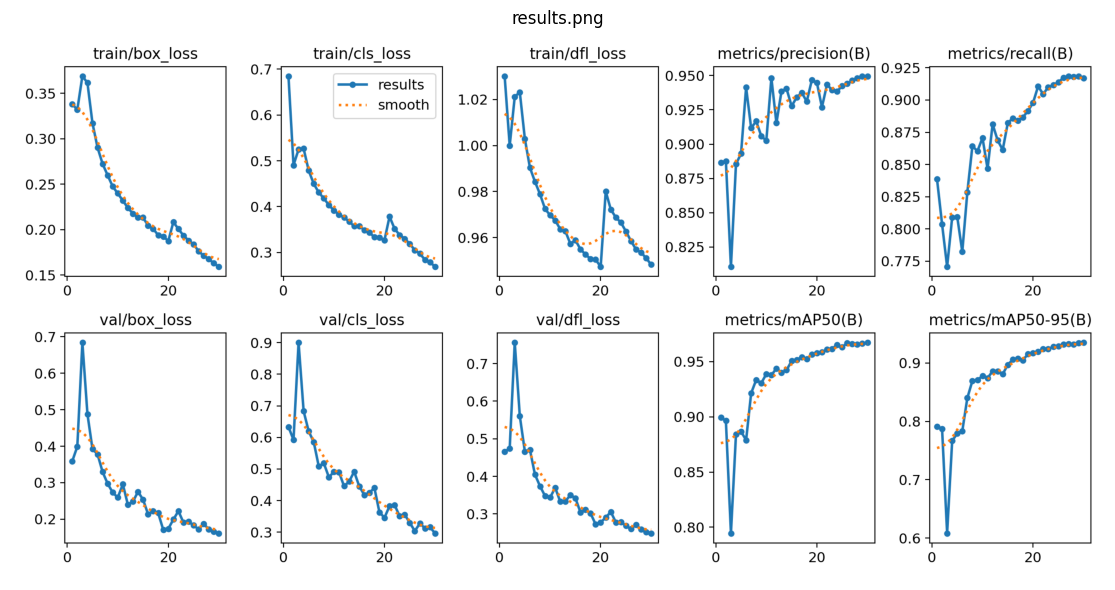

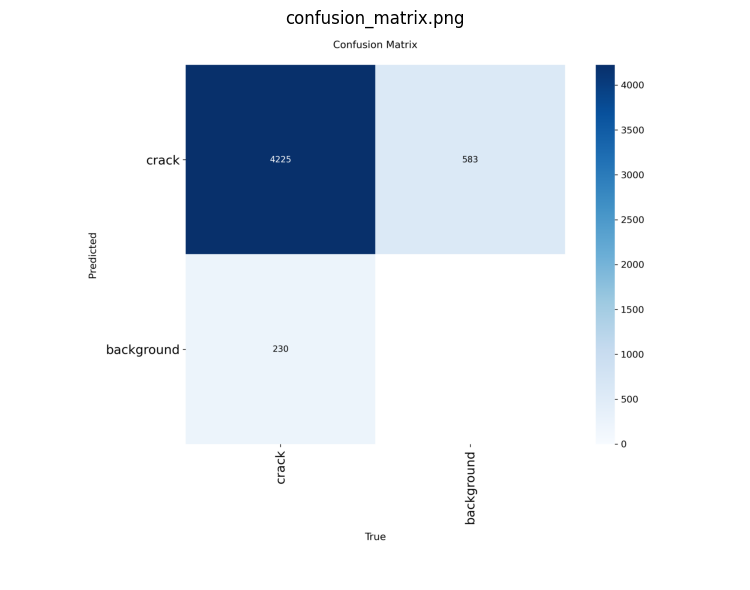

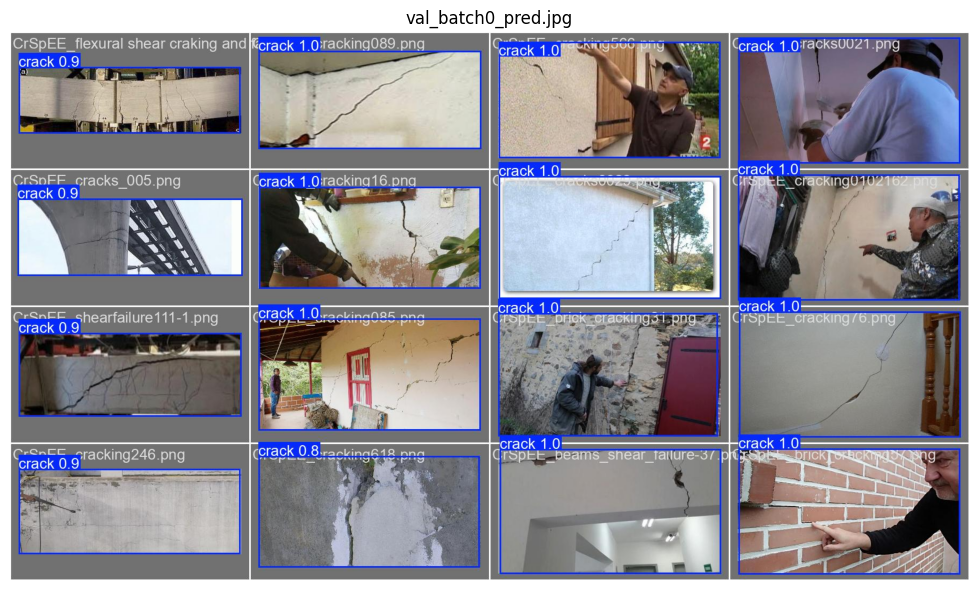

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for plot_file in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = run_dir / plot_file
    if p.exists():
        img = mpimg.imread(str(p))
        plt.figure(figsize=(14, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot_file)
        plt.tight_layout()
        plt.show()


In [ ]:
import random, cv2

sample_imgs = random.sample(test_imgs, min(4, len(test_imgs)))
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('YOLOv8 Predictions — Test Samples')

for ax, img_path in zip(axes, sample_imgs):
    result = best_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/predictions_sample.png', dpi=150)
plt.show()


## 7. Save to Drive

In [13]:
import shutil, json

DRIVE_CKPT  = DRIVE_DIR / 'checkpoints' / 'detector'
DRIVE_PLOTS = DRIVE_DIR / 'plots' / 'detector'
DRIVE_CKPT.mkdir(parents=True, exist_ok=True)
DRIVE_PLOTS.mkdir(parents=True, exist_ok=True)

for w in ['best.pt', 'last.pt']:
    src = run_dir / 'weights' / w
    if src.exists():
        shutil.copy2(src, DRIVE_CKPT / w)

for f in list(run_dir.glob('*.png')) + list(run_dir.glob('*.jpg')):
    shutil.copy2(f, DRIVE_PLOTS / f.name)

pred_sample = Path('/content/predictions_sample.png')
if pred_sample.exists():
    shutil.copy2(pred_sample, DRIVE_PLOTS / pred_sample.name)

summary = {
    'map50':     float(metrics.box.map50),
    'map50_95':  float(metrics.box.map),
    'precision': float(metrics.box.mp),
    'recall':    float(metrics.box.mr),
}
(DRIVE_CKPT / 'metrics.json').write_text(json.dumps(summary, indent=2))

print("Saved to Drive:")
for f in sorted(DRIVE_CKPT.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")
print(f"\nmAP@50 : {summary['map50']:.4f}  (target >0.70)")


Saved to Drive:
  best.pt  (22.5 MB)
  last.pt  (22.5 MB)
  metrics.json  (0.0 MB)

mAP@50 : 0.3459  (target >0.70)
